In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation
from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
DATA_PATH = "D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt"

file = glob.glob(f"{DATA_PATH}")
file

['D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt']

In [3]:
# Load keypoints from output.txt and display shape
keypoints = np.loadtxt(file[0])
print('Keypoints shape:', keypoints.shape)

def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

Keypoints shape: (181, 56)


In [4]:
coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

def plot_line(axs, pt1, pt2, **kwargs):
    """
    Plots a line between two points on the given matplotlib axis.
    pt1, pt2: (x, y) tuples or arrays
    axs: matplotlib axis object
    kwargs: additional arguments for axs.plot (e.g., color, linewidth)
    """
    x_values = [pt1[0], pt2[0]]
    y_values = [pt1[1], pt2[1]]
    axs.plot(x_values, y_values, **kwargs)

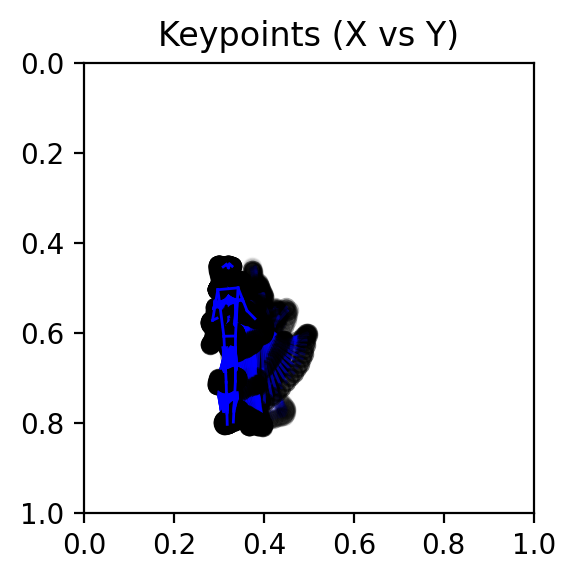

In [5]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
alpha = 0
nodes = np.zeros([180,17,2])
edges = np.zeros([180,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(180):
    alpha += 1.0 / 180  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha = alpha)  # Plot keypoints as red dots
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    for i in range(16):
        plot_line(axs, edges[t][i][0], edges[t][i][1], color='blue', linewidth=1, alpha=alpha)  # Plot edges as blue lines

axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
axs.set_title('Keypoints (X vs Y)')
plt.tight_layout()
plt.show()

In [6]:
def calculate_node_velocity(nodes, dt=1.0):
    """
    Calculate the velocity of each node over time.
    nodes: numpy array of shape (frames, num_nodes, 2) with (x, y) positions.
    dt: time difference between frames (default 1.0, set to actual frame interval if known).
    Returns:
        velocities: numpy array of shape (frames-1, num_nodes, 2) with (vx, vy) velocities.
        speeds: numpy array of shape (frames-1, num_nodes) with speed magnitudes.
    """
    velocities = (nodes[1:] - nodes[:-1]) / dt
    speeds = np.linalg.norm(velocities, axis=2)
    return velocities, speeds

**DATASET**

In [7]:
import numpy as np
import torch
import glob
import os
from torch.utils.data import Dataset

def normalize(data, data_max, data_min):
    return (data - data_min) * 2 / (data_max - data_min) - 1

def unnormalize(data, data_max, data_min):
    return (data + 1) * (data_max - data_min) / 2 + data_min

class PoseDataset(Dataset):
    def __init__(self, data_path, mode, pitch_type, data_len=-1, test_full=False):
        self.data_path = data_path
        self.mode = mode
        self.pitch_type = pitch_type
        self.train_data_len = data_len
        self.test_full = test_full

        # 1. Glob training files to establish normalization baselines
        train_files = glob.glob(os.path.join(data_path, 'train', pitch_type, '*.txt'))
        if not train_files:
            raise ValueError(f"No training files found in {os.path.join(data_path, 'train', pitch_type)}")
            
        train_locs, train_vels = self._load_and_process_files(train_files)

        # 2. Calculate min/max values across the entire training set for normalization
        self.loc_max = max(loc.max() for loc in train_locs)
        self.loc_min = min(loc.min() for loc in train_locs)
        self.vel_max = max(vel.max() for vel in train_vels)
        self.vel_min = min(vel.min() for vel in train_vels)

        # 3. Load the requested split (train, val, or test)
        if mode == 'train':
            split_locs, split_vels = train_locs, train_vels
        else:
            split_files = glob.glob(os.path.join(data_path, mode, pitch_type, '*.txt'))
            split_locs, split_vels = self._load_and_process_files(split_files)

        # 4. Normalize and build the final feature tensors
        self.feat = []
        for loc, vel in zip(split_locs, split_vels):
            loc_norm = normalize(loc, self.loc_max, self.loc_min)
            vel_norm = normalize(vel, self.vel_max, self.vel_min)
            
            # Concatenate loc and vel into shape: (frames, 17, 4)
            combined = np.concatenate([loc_norm, vel_norm], axis=-1).astype(np.float32)
            
            # Truncate test sequences if requested
            if self.mode == 'test' and not self.test_full:
                combined = combined[:49]
                
            self.feat.append(torch.from_numpy(combined))

    def _load_and_process_files(self, file_paths):
        """Helper to load .txt files, extract 17 keypoints, and compute velocity."""
        all_locs = []
        all_vels = []
        
        for file_path in file_paths:
            # Load text file -> shape: (frames, 56)
            data = np.loadtxt(file_path)
            frames = data.shape[0]
            
            # Extract x, y coordinates for the 17 nodes
            # Index logic: columns 5 to 55 are organized as [x, y, conf]
            loc = np.zeros((frames, 17, 2))
            for i in range(17):
                loc[:, i, 0] = data[:, 5 + i*3]      # x coordinate
                loc[:, i, 1] = data[:, 5 + i*3 + 1]  # y coordinate
                
            # Calculate velocities (forward difference)
            # Pad the first frame with 0s to maintain the exact same shape as 'loc'
            vel = np.zeros_like(loc)
            vel[1:] = loc[1:] - loc[:-1]  # Assuming dt=1.0 per frame
            
            all_locs.append(loc)
            all_vels.append(vel)
            
        return all_locs, all_vels

    def __getitem__(self, index):
        inputs = self.feat[index]

        # Dynamic slicing during training
        if self.mode == 'train' and self.train_data_len > 0:
            size = len(inputs)
            if size > self.train_data_len:
                start_ind = np.random.randint(0, size - self.train_data_len)
                inputs = inputs[start_ind:start_ind + self.train_data_len]

        return {'inputs': inputs}

    def __len__(self):
        return len(self.feat)

In [8]:
DATA_PATH = "D:/GitHub/BaseballPitch/data/finetuning_dataset/labels"
PITCH_TYPE = 'CH - Changeup'
SEQ_LEN = 98

train_data = PoseDataset(DATA_PATH, 'train', PITCH_TYPE)
val_data = PoseDataset(DATA_PATH, 'val', PITCH_TYPE)
test_data = PoseDataset(DATA_PATH, 'test', PITCH_TYPE, test_full=True)


In [9]:
# Find the smallest shape (fewest frames) for each of the 5 pitch types in train set
pitch_types = [
    'CH - Changeup',
    'FF - Fastball',
    'SI - Sinker',
    'SL - Slider',
    'ST - Sweeper'
]

smallest_shapes = {}
for pitch in pitch_types:
    files = glob.glob(os.path.join(DATA_PATH, 'train', pitch, '*.txt'))
    min_shape = None
    min_file = None
    for f in files:
        arr = np.loadtxt(f)
        if min_shape is None or arr.shape[0] < min_shape:
            min_shape = arr.shape[0]
            min_file = f
    smallest_shapes[pitch] = {'file': min_file, 'shape': min_shape}

for pitch, info in smallest_shapes.items():
    print(f"{pitch}: {info['file']} (frames: {info['shape']})")

CH - Changeup: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\CH - Changeup\PitchType-CH_Zone-13_PlayID-e18b54da-3bfe-340c-9c73-aa4e02011444_Date-2025-06-17.txt (frames: 177)
FF - Fastball: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\FF - Fastball\PitchType-FF_Zone-2_PlayID-f5fb9270-8bbc-3de5-94be-aed63b87d29f_Date-2025-06-05.txt (frames: 176)
SI - Sinker: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\SI - Sinker\PitchType-SI_Zone-3_PlayID-7efb69ed-3887-3381-bf9e-d5161760555d_Date-2025-05-02.txt (frames: 176)
SL - Slider: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\SL - Slider\PitchType-SL_Zone-9_PlayID-0b59b126-36d2-4e8c-a2f7-a60d4c4adae9_Date-2024-09-27.txt (frames: 177)
ST - Sweeper: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\ST - Sweeper\PitchType-ST_Zone-9_PlayID-400ea70b-e59a-3129-bb27-212695c76701_Date-2025-06-28.txt (frames: 177)


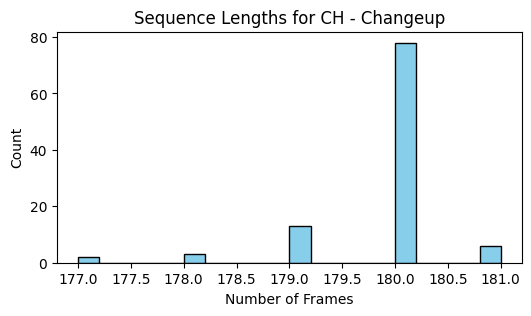

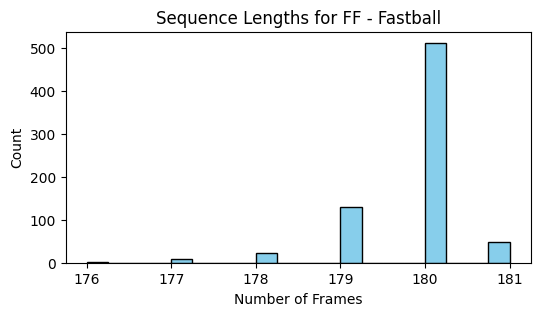

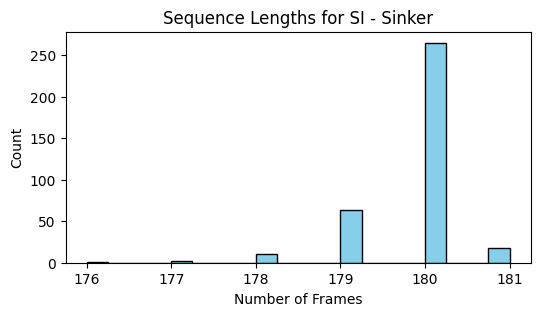

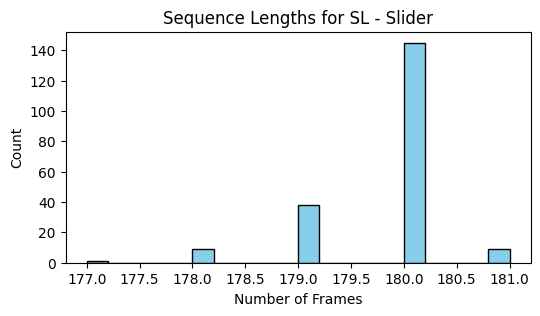

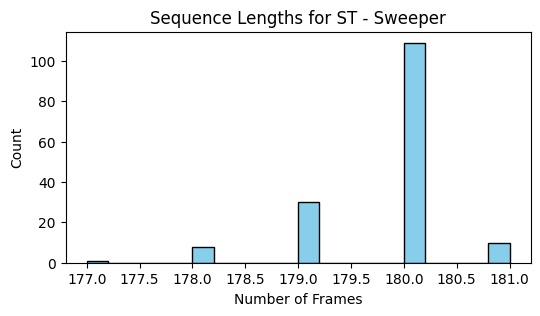

In [10]:
import matplotlib.pyplot as plt

# Plot a histogram for each pitch type showing the length of each sequence
for pitch in pitch_types:
    files = glob.glob(os.path.join(DATA_PATH, 'train', pitch, '*.txt'))
    lengths = [np.loadtxt(f).shape[0] for f in files]
    plt.figure(figsize=(6, 3))
    plt.hist(lengths, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Sequence Lengths for {pitch}')
    plt.xlabel('Number of Frames')
    plt.ylabel('Count')
    plt.show()

In [13]:
# Find the file with the most frames for each pitch type in the train set
max_shapes = {}
for pitch in pitch_types:
    files = glob.glob(os.path.join(DATA_PATH, 'train', pitch, '*.txt'))
    max_shape = None
    max_file = None
    for f in files:
        arr = np.loadtxt(f)
        if max_shape is None or arr.shape[0] > max_shape:
            max_shape = arr.shape[0]
            max_file = f
    max_shapes[pitch] = {'file': max_file, 'shape': max_shape}

for pitch, info in max_shapes.items():
    print(f"{pitch}: {info['file']} (frames: {info['shape']})")

CH - Changeup: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\CH - Changeup\PitchType-CH_Zone-11_PlayID-51b20068-1138-3d15-a8d8-8c8fc3707145_Date-2025-05-13.txt (frames: 181)
FF - Fastball: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\FF - Fastball\PitchType-FF_Zone-11_PlayID-0cb307cb-94e8-46fe-85fd-80066c44ff59_Date-2024-08-19.txt (frames: 181)
SI - Sinker: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\SI - Sinker\PitchType-SI_Zone-11_PlayID-a0d99fb8-ecb1-4a65-b604-74e7812813e9_Date-2023-07-29.txt (frames: 181)
SL - Slider: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\SL - Slider\PitchType-SL_Zone-14_PlayID-41f44988-39ac-3a5e-ae1e-94390b6de87f_Date-2025-05-30.txt (frames: 181)
ST - Sweeper: D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\ST - Sweeper\PitchType-ST_Zone-14_PlayID-2a403a22-94a1-4d8f-8a79-11a307cd4c4c_Date-2024-08-14.txt (frames: 181)


In [18]:
def txt_files_over_n_lines(root_dir, n=90):
    result = []
    for dirpath, _, _ in os.walk(root_dir):
        for file in glob.glob(os.path.join(dirpath, '*.txt')):
            try:
                with open(file, 'r') as f:
                    line_count = sum(1 for _ in f)
                if line_count < n:
                    result.append((file, line_count))
            except Exception as e:
                print(f"Error reading {file}: {e}")
    return result

root_dir = 'D:/GitHub/BaseballPitch/data/finetuning_dataset/labels'
files_over_180 = txt_files_over_n_lines(root_dir, 177)
for file, count in files_over_180:
    print(f"{file} ({count} lines)")

D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\test\SI - Sinker\PitchType-SI_Zone-9_PlayID-f07d60d2-de7f-34cb-91fe-be01277a0354_Date-2025-09-19.txt (176 lines)
D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\FF - Fastball\PitchType-FF_Zone-2_PlayID-f5fb9270-8bbc-3de5-94be-aed63b87d29f_Date-2025-06-05.txt (176 lines)
D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\FF - Fastball\PitchType-FF_Zone-6_PlayID-0dd45659-7347-3942-a411-3da9ac2ad872_Date-2025-05-02.txt (176 lines)
D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\train\SI - Sinker\PitchType-SI_Zone-3_PlayID-7efb69ed-3887-3381-bf9e-d5161760555d_Date-2025-05-02.txt (176 lines)
D:/GitHub/BaseballPitch/data/finetuning_dataset/labels\val\CH - Changeup\PitchType-CH_Zone-14_PlayID-eb25d24c-396a-3f7c-bdb5-92c1af06509f_Date-2025-07-20.txt (176 lines)
